# PDF Corpus EDA — RAG / NLP Track (Milestone 2)

This notebook covers the full EDA pipeline for the PDF corpus used in the MuRIL-based RAG
system: UP government scheme PDFs + any other PDF sources split across **4 folders**.

**Pipeline:**
1. Configuration (folder paths)
2. Build a document inventory (filename, size, page count, folder/source)
3. Extract text (native extraction with pdfplumber, OCR fallback with pytesseract)
4. Corpus-level EDA: page/word counts, language distribution, duplicates, empty extractions, garbage-character ratio, date/year extraction
5. Visualizations
6. Save all outputs (inventory CSV, extracted text files, EDA summary)

> Adjust `FOLDER_PATHS` below to point at your 4 actual folders before running.


In [23]:
# Install dependencies (uncomment if running fresh)
!pip install pdfplumber PyMuPDF pytesseract pdf2image langdetect pandas matplotlib seaborn tqdm --break-system-packages
# Note: pytesseract also needs the `tesseract-ocr` binary + `tesseract-ocr-hin` (Hindi) language pack installed at the OS level.
# Note: pdf2image needs `poppler-utils` installed at the OS level.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import os
import re
import glob
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import pdfplumber
import fitz  # PyMuPDF, used as a fallback / for quick metadata

try:
    from langdetect import detect, DetectorFactory
    DetectorFactory.seed = 0
    LANGDETECT_AVAILABLE = True
except ImportError:
    LANGDETECT_AVAILABLE = False

try:
    import pytesseract
    from pdf2image import convert_from_path
    OCR_AVAILABLE = True
except ImportError:
    OCR_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


## 1. Configuration

Point each key at one of your 4 source folders. The folder name becomes the `source` label used throughout the EDA (e.g. to compare corpora by origin).

In [25]:
FOLDER_PATHS = {
    "other_docs":        "../data/raw/pdfs/Other_docs",
    "ppqs_advisories":     "../data/raw/pdfs/PPQS_Advisories",
    "schemes": "../data/raw/pdfs/Schemes",
    "up_acp":         "../data/raw/pdfs/UP_ACP_PDFs",
}

# Where extracted text + outputs will be saved
OUTPUT_DIR = "../data/raw/pdfs/pdf_eda_outputs"
TEXT_DIR = os.path.join(OUTPUT_DIR, "extracted_text")
os.makedirs(TEXT_DIR, exist_ok=True)

# OCR is slow -- cap pages OCR'd per doc if a doc is huge (safety valve)
MAX_OCR_PAGES = 30
OCR_DPI = 200


## 2. Build Document Inventory

Walk each folder, collect filename, size, page count, and a content-hash (for later duplicate detection).

In [26]:
def safe_path(path):
    """Work around the Windows MAX_PATH (260 char) limit by using the \\?\ prefix."""
    abs_path = os.path.abspath(path)
    if os.name == "nt" and not abs_path.startswith("\\\\?\\"):
        return "\\\\?\\" + abs_path
    return abs_path

def file_hash(path, block_size=65536):
    h = hashlib.sha256()
    with open(safe_path(path), "rb") as f:
        for block in iter(lambda: f.read(block_size), b""):
            h.update(block)
    return h.hexdigest()

def get_page_count(path):
    try:
        with fitz.open(safe_path(path)) as doc:
            return doc.page_count
    except Exception:
        return None

records = []
for source, folder in FOLDER_PATHS.items():
    if not os.path.isdir(folder):
        print(f"[WARN] Folder not found, skipping: {folder}")
        continue
    pdf_files = glob.glob(os.path.join(folder, "**", "*.pdf"), recursive=True)
    for path in pdf_files:
        records.append({
            "source": source,
            "filename": os.path.basename(path),
            "filepath": path,
            "size_kb": round(os.path.getsize(safe_path(path)) / 1024, 1),
            "page_count": get_page_count(path),
            "file_hash": file_hash(path),
        })

inventory_df = pd.DataFrame(records)
print(f"Total PDFs found: {len(inventory_df)}")
inventory_df.head()

Total PDFs found: 187


,source,filename,filepath,size_kb,page_count,file_hash
0,other_docs,CMP_Circulars_29102025_638973560481999250_Rabi...,../data/raw/pdfs/Other_docs\CMP_Circulars_2910...,2178.2,8,3e154fdec3526b3bfa17cb0d9dba4e7614e9b81e55da75...
1,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,../data/raw/pdfs/Other_docs\EB-52-Wheat-Cultiv...,950.9,40,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-FOR-...,530.3,2,226bd391ee98477bad05aeda38752b8bee812a2ccf1a99...
3,other_docs,ICAR-Advisory-March-1-152026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-Marc...,409.0,1,ae2c3962ed11683f7cca00177270f4ec28728f9c243783...
4,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...


In [27]:
# Exact duplicate check via file hash (catches identical re-uploads across folders)
dupe_hashes = inventory_df["file_hash"].value_counts()
dupe_hashes = dupe_hashes[dupe_hashes > 1]
print(f"Exact-duplicate files (by content hash): {dupe_hashes.sum() - len(dupe_hashes)} redundant copies across {len(dupe_hashes)} groups")

inventory_df["is_exact_duplicate"] = inventory_df["file_hash"].isin(dupe_hashes.index)
inventory_df[inventory_df["is_exact_duplicate"]].sort_values("file_hash")


Exact-duplicate files (by content hash): 2 redundant copies across 2 groups


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate
46,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,../data/raw/pdfs/PPQS_Advisories\Advisory on i...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
47,ppqs_advisories,Advisory on incidence of Fall Army Worm (FAW) ...,../data/raw/pdfs/PPQS_Advisories\Advisory on i...,1461.9,2,2f43ff3ca3dc668edd9f78aaa8dd76d944894ade72bbbd...,True
136,up_acp,FAIZABAD.pdf,../data/raw/pdfs/UP_ACP_PDFs\FAIZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True
139,up_acp,FIROZABAD.pdf,../data/raw/pdfs/UP_ACP_PDFs\FIROZABAD.pdf,1040.0,28,e6813a32c3f1460c62edb889717932d7b6ad65754fe1de...,True


## 3. Text Extraction (native + OCR fallback)

Strategy per the pdf-reading skill:
- Trying `pdfplumber` first (fast, works for text-native PDFs).
- If extracted text is empty/near-empty (common for scanned government PDFs), fall back to OCR via `pytesseract` on rasterized pages.
- Track `extraction_method` per document

In [28]:
def extract_native_text(path):
    text_parts = []
    try:
        with pdfplumber.open(safe_path(path)) as pdf:
            for page in pdf.pages:
                t = page.extract_text() or ""
                text_parts.append(t)
    except Exception as e:
        return "", f"error: {e}"
    return "\n".join(text_parts), None

def extract_ocr_text(path, max_pages=MAX_OCR_PAGES, dpi=OCR_DPI):
    if not OCR_AVAILABLE:
        return "", "ocr_unavailable"
    try:
        images = convert_from_path(safe_path(path), dpi=dpi)
    except Exception as e:
        return "", f"error: {e}"
    text_parts = []
    for img in images[:max_pages]:
        # lang='eng+hin' requires the Hindi tesseract language pack installed
        t = pytesseract.image_to_string(img, lang="eng+hin")
        text_parts.append(t)
    return "\n".join(text_parts), None

def is_near_empty(text, min_chars=50):
    return len(text.strip()) < min_chars

extraction_rows = []
for _, row in tqdm(inventory_df.iterrows(), total=len(inventory_df)):
    path = row["filepath"]
    native_text, native_err = extract_native_text(path)
    method = "native"
    err = native_err

    if is_near_empty(native_text):
        ocr_text, ocr_err = extract_ocr_text(path)
        if not is_near_empty(ocr_text):
            native_text = ocr_text
            method = "ocr"
            err = ocr_err
        else:
            method = "failed"
            err = ocr_err or "empty_after_ocr"

    # Save extracted text to disk, one .txt per PDF, mirrored under source folder
    out_dir = os.path.join(TEXT_DIR, row["source"])
    os.makedirs(safe_path(out_dir), exist_ok=True)
    txt_filename = os.path.splitext(row["filename"])[0] + ".txt"
    out_path = os.path.join(out_dir, txt_filename)
    with open(safe_path(out_path), "w", encoding="utf-8") as f:
        f.write(native_text)

    extraction_rows.append({
        "filepath": path,
        "extraction_method": method,
        "extraction_error": err,
        "char_count": len(native_text),
        "word_count": len(native_text.split()),
        "text_output_path": out_path,
    })

extraction_df = pd.DataFrame(extraction_rows)
inventory_df = inventory_df.merge(extraction_df, on="filepath", how="left")
inventory_df.head()

100%|██████████| 187/187 [13:53<00:00,  4.46s/it] 


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate,extraction_method,extraction_error,char_count,word_count,text_output_path
0,other_docs,CMP_Circulars_29102025_638973560481999250_Rabi...,../data/raw/pdfs/Other_docs\CMP_Circulars_2910...,2178.2,8,3e154fdec3526b3bfa17cb0d9dba4e7614e9b81e55da75...,False,native,None,9843,1613,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...
1,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,../data/raw/pdfs/Other_docs\EB-52-Wheat-Cultiv...,950.9,40,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...,False,native,None,45289,7451,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-FOR-...,530.3,2,226bd391ee98477bad05aeda38752b8bee812a2ccf1a99...,False,failed,error: Unable to get page count. Is poppler in...,1,0,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...
3,other_docs,ICAR-Advisory-March-1-152026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-Marc...,409.0,1,ae2c3962ed11683f7cca00177270f4ec28728f9c243783...,False,failed,error: Unable to get page count. Is poppler in...,0,0,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...
4,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,340.7,1,72bce060c89fea887b71c8a6d76b05d666bc1a7541d078...,False,failed,error: Unable to get page count. Is poppler in...,0,0,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...


## 4. Corpus-Level EDA

### 4.1 Summary statistics

In [29]:
summary = inventory_df.groupby("source").agg(
    num_docs=("filename", "count"),
    total_pages=("page_count", "sum"),
    avg_pages=("page_count", "mean"),
    avg_words=("word_count", "mean"),
    ocr_docs=("extraction_method", lambda x: (x == "ocr").sum()),
    failed_docs=("extraction_method", lambda x: (x == "failed").sum()),
).round(1)
summary


,num_docs,total_pages,avg_pages,avg_words,ocr_docs,failed_docs
source,,,,,,
other_docs,12,189,15.8,5566.5,0,5
ppqs_advisories,90,444,4.9,1302.4,0,9
schemes,11,359,32.6,8956.5,0,0
up_acp,74,1805,24.4,4579.7,0,0


### 4.2 Missing / near-empty extraction analysis

In [30]:
failed_df = inventory_df[inventory_df["extraction_method"] == "failed"]
print(f"Documents with failed/near-empty extraction: {len(failed_df)} / {len(inventory_df)}")
failed_df[["source", "filename", "page_count", "char_count"]]


Documents with failed/near-empty extraction: 14 / 187


,source,filename,page_count,char_count
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,2,1
3,other_docs,ICAR-Advisory-March-1-152026.pdf,1,0
4,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,1,0
5,other_docs,ICAR-Advisory-WHEAT-April-16-302026.pdf,1,0
7,other_docs,Integrated pest management.pdf,3,2
26,ppqs_advisories,Advisory on Aphid on Mustard crop growing area...,3,2
28,ppqs_advisories,Advisory on Black headed caterpillar and Leaf ...,3,2
29,ppqs_advisories,Advisory on Black headed caterpillar in Coconu...,3,2
41,ppqs_advisories,Advisory on Fusarium Wilt (panama disease) on ...,2,1
63,ppqs_advisories,Advisory on Mango leaf hopper and Mealy bug in...,3,2


In [31]:
# Retry failed docs at higher DPI before giving up on them
RETRY_DPI = 300

retry_results = []
for _, row in failed_df.iterrows():
    path = row["filepath"]
    ocr_text, ocr_err = extract_ocr_text(path, dpi=RETRY_DPI)
    if not is_near_empty(ocr_text):
        # Success on retry -- overwrite the saved text file
        with open(row["text_output_path"], "w", encoding="utf-8") as f:
            f.write(ocr_text)
        status = "recovered_on_retry"
        char_count = len(ocr_text)
        word_count = len(ocr_text.split())
    else:
        status = "excluded_unreadable"
        char_count = row["char_count"]
        word_count = 0

    retry_results.append({
        "filepath": path,
        "retry_status": status,
        "char_count": char_count,
        "word_count": word_count,
    })

retry_df = pd.DataFrame(retry_results)

# Merge retry outcomes back into inventory_df
inventory_df = inventory_df.merge(
    retry_df[["filepath", "retry_status"]], on="filepath", how="left"
)
inventory_df["retry_status"] = inventory_df["retry_status"].fillna("not_applicable")

# Update extraction_method + counts for recovered docs
for _, r in retry_df.iterrows():
    mask = inventory_df["filepath"] == r["filepath"]
    if r["retry_status"] == "recovered_on_retry":
        inventory_df.loc[mask, "extraction_method"] = "ocr_retry"
        inventory_df.loc[mask, "char_count"] = r["char_count"]
        inventory_df.loc[mask, "word_count"] = r["word_count"]
    else:
        inventory_df.loc[mask, "extraction_method"] = "excluded_unreadable"

recovered = (inventory_df["retry_status"] == "recovered_on_retry").sum()
excluded = (inventory_df["retry_status"] == "excluded_unreadable").sum()
print(f"Recovered on retry: {recovered}")
print(f"Still unreadable, excluded from corpus: {excluded}")

inventory_df[inventory_df["retry_status"] == "excluded_unreadable"][["source", "filename", "page_count"]]

Recovered on retry: 0
Still unreadable, excluded from corpus: 14


,source,filename,page_count
2,other_docs,ICAR-Advisory-FOR-SOWING-March-16-312026.pdf,2
3,other_docs,ICAR-Advisory-March-1-152026.pdf,1
4,other_docs,ICAR-Advisory-WHEAT-April-1-152026.pdf,1
5,other_docs,ICAR-Advisory-WHEAT-April-16-302026.pdf,1
7,other_docs,Integrated pest management.pdf,3
26,ppqs_advisories,Advisory on Aphid on Mustard crop growing area...,3
28,ppqs_advisories,Advisory on Black headed caterpillar and Leaf ...,3
29,ppqs_advisories,Advisory on Black headed caterpillar in Coconu...,3
41,ppqs_advisories,Advisory on Fusarium Wilt (panama disease) on ...,2
63,ppqs_advisories,Advisory on Mango leaf hopper and Mealy bug in...,3


In [32]:
# Final exclusion list -- these are permanently dropped from the RAG corpus
excluded_df = inventory_df[inventory_df["extraction_method"] == "excluded_unreadable"].copy()

print(f"Final excluded (unreadable) documents: {len(excluded_df)}")
excluded_df[["source", "filename", "page_count", "size_kb"]]

# Save the exclusion list separately -- this is your audit trail for Section 11 (Challenges)
excluded_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_unreadable_docs.csv"), index=False)

# Clean corpus = everything except excluded docs
clean_inventory_df = inventory_df[inventory_df["extraction_method"] != "excluded_unreadable"].copy()
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Final excluded (unreadable) documents: 14

Final clean corpus: 173 / 187 documents


### 4.3 Duplicate analysis (exact + near-duplicate)

In [33]:
# Exact duplicates already flagged via file_hash above.
# Near-duplicate check on extracted text (e.g. same circular re-uploaded with a different cover page)
from difflib import SequenceMatcher

def text_similarity(a, b, sample_chars=3000):
    return SequenceMatcher(None, a[:sample_chars], b[:sample_chars]).ratio()

texts = {}
for _, row in inventory_df.iterrows():
    if row["extraction_method"] != "failed" and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            texts[row["filepath"]] = f.read()

near_dupes = []
paths = list(texts.keys())
for i in range(len(paths)):
    for j in range(i + 1, len(paths)):
        sim = text_similarity(texts[paths[i]], texts[paths[j]])
        if sim > 0.9:
            near_dupes.append((paths[i], paths[j], round(sim, 3)))

near_dupes_df = pd.DataFrame(near_dupes, columns=["file_a", "file_b", "similarity"])
print(f"Near-duplicate pairs found (similarity > 0.90): {len(near_dupes_df)}")
near_dupes_df


Near-duplicate pairs found (similarity > 0.90): 33


,file_a,file_b,similarity
0,../data/raw/pdfs/Other_docs\ICAR-Advisory-FOR-...,../data/raw/pdfs/PPQS_Advisories\Advisory on F...,1.000
1,../data/raw/pdfs/Other_docs\ICAR-Advisory-FOR-...,../data/raw/pdfs/PPQS_Advisories\Advisory on M...,1.000
2,../data/raw/pdfs/Other_docs\ICAR-Advisory-FOR-...,../data/raw/pdfs/PPQS_Advisories\Advisory on n...,1.000
3,../data/raw/pdfs/Other_docs\ICAR-Advisory-Marc...,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,1.000
4,../data/raw/pdfs/Other_docs\ICAR-Advisory-Marc...,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,1.000
5,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,../data/raw/pdfs/Other_docs\ICAR-Advisory-WHEA...,1.000
6,../data/raw/pdfs/Other_docs\Integrated pest ma...,../data/raw/pdfs/PPQS_Advisories\Advisory on A...,1.000
7,../data/raw/pdfs/Other_docs\Integrated pest ma...,../data/raw/pdfs/PPQS_Advisories\Advisory on B...,1.000
8,../data/raw/pdfs/Other_docs\Integrated pest ma...,../data/raw/pdfs/PPQS_Advisories\Advisory on B...,1.000
9,../data/raw/pdfs/Other_docs\Integrated pest ma...,../data/raw/pdfs/PPQS_Advisories\Advisory on M...,1.000


In [34]:
# Resolve near-duplicates: keep the file with more words per pair (or native over OCR if tied), drop the other
near_dupes_df["a_filename"] = near_dupes_df["file_a"].apply(lambda p: os.path.basename(p))
near_dupes_df["b_filename"] = near_dupes_df["file_b"].apply(lambda p: os.path.basename(p))
near_dupes_df["a_words"] = near_dupes_df["file_a"].map(inventory_df.set_index("filepath")["word_count"])
near_dupes_df["b_words"] = near_dupes_df["file_b"].map(inventory_df.set_index("filepath")["word_count"])

to_drop = set()
for _, row in near_dupes_df.iterrows():
    a, b = row["file_a"], row["file_b"]
    if a in to_drop or b in to_drop:
        continue  # already resolved via a chained duplicate
    if row["a_words"] >= row["b_words"]:
        to_drop.add(b)
    else:
        to_drop.add(a)

print(f"Files marked for removal as near-duplicates: {len(to_drop)}")

inventory_df["is_near_duplicate_dropped"] = inventory_df["filepath"].isin(to_drop)
near_dupe_dropped_df = inventory_df[inventory_df["is_near_duplicate_dropped"]][["source", "filename", "word_count"]]
print(near_dupe_dropped_df)

# Update clean_inventory_df: remove near-duplicates on top of the earlier unreadable exclusion
clean_inventory_df = clean_inventory_df[~clean_inventory_df["filepath"].isin(to_drop)].copy()

# Save updated audit trail
near_dupe_dropped_df.to_csv(os.path.join(OUTPUT_DIR, "excluded_near_duplicate_docs.csv"), index=False)
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)

print(f"\nFinal clean corpus after both exclusions: {len(clean_inventory_df)} / {len(inventory_df)} documents")

Files marked for removal as near-duplicates: 14
              source                                           filename  \
4         other_docs             ICAR-Advisory-WHEAT-April-1-152026.pdf   
5         other_docs            ICAR-Advisory-WHEAT-April-16-302026.pdf   
26   ppqs_advisories  Advisory on Aphid on Mustard crop growing area...   
28   ppqs_advisories  Advisory on Black headed caterpillar and Leaf ...   
29   ppqs_advisories  Advisory on Black headed caterpillar in Coconu...   
41   ppqs_advisories  Advisory on Fusarium Wilt (panama disease) on ...   
47   ppqs_advisories  Advisory on incidence of Fall Army Worm (FAW) ...   
63   ppqs_advisories  Advisory on Mango leaf hopper and Mealy bug in...   
64   ppqs_advisories  Advisory on Mango Thrips in Mango growing area...   
65   ppqs_advisories  Advisory on new exotic, invasive and destructi...   
73   ppqs_advisories  Advisory on White Fly on Brinjal growing areas...   
75   ppqs_advisories  Advisory on Whitefly on Chilli

### 4.4 Language distribution

In [35]:
def detect_language(text, sample_chars=1000):
    sample = text[:sample_chars].strip()
    if not sample:
        return "unknown"
    if LANGDETECT_AVAILABLE:
        try:
            return detect(sample)
        except Exception:
            pass
    # crude fallback: proportion of Devanagari characters
    devanagari = len(re.findall(r"[\u0900-\u097F]", sample))
    return "hi" if devanagari / max(len(sample), 1) > 0.3 else "en"

languages = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            languages.append(detect_language(f.read()))
    else:
        languages.append("unknown")

clean_inventory_df["detected_language"] = languages
clean_inventory_df["detected_language"].value_counts()


detected_language
en         154
unknown     14
cy           1
ca           1
Name: count, dtype: int64

### 4.5 Garbage-character / OCR-quality check

In [36]:
def garbage_ratio(text, sample_chars=2000):
    sample = text[:sample_chars]
    if not sample.strip():
        return 1.0
    valid = len(re.findall(r"[a-zA-Z0-9\u0900-\u097F\s.,;:()\-]", sample))
    return round(1 - (valid / len(sample)), 3)

garbage_scores = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            garbage_scores.append(garbage_ratio(f.read()))
    else:
        garbage_scores.append(None)

clean_inventory_df["garbage_char_ratio"] = garbage_scores
clean_inventory_df[clean_inventory_df["garbage_char_ratio"] > 0.15][["source", "filename", "extraction_method", "garbage_char_ratio"]]


,source,filename,extraction_method,garbage_char_ratio


### 4.6 Document date / freshness check (heuristic)

Looks for a 4-digit year in the filename or extracted text to flag potentially outdated scheme documents.

In [37]:
def extract_year(text_or_name):
    all_years = re.findall(r"\b(19\d{2}|20\d{2})\b", text_or_name)
    return max(map(int, all_years)) if all_years else None

detected_years = []
for _, row in clean_inventory_df.iterrows():
    year = extract_year(row["filename"])
    if year is None and os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            year = extract_year(f.read()[:2000])
    detected_years.append(year)

clean_inventory_df["detected_year"] = detected_years
clean_inventory_df["detected_year"].value_counts(dropna=False).sort_index()


detected_year
1968.0     1
2007.0     2
2014.0     2
2016.0     1
2017.0     1
2018.0     6
2019.0     8
2020.0     6
2021.0     2
2022.0    18
2023.0    12
2024.0     6
2025.0     4
2026.0     2
NaN       99
Name: count, dtype: int64

# 4.7 Word Frequency Analysis

In [38]:
import re
from collections import Counter

ENGLISH_STOPWORDS = set("""
the a an is are was were be been being of to in on for and or with as at by from
this that these those it its it's he she they them his her their we you your i
not no yes will shall can could would should may might must have has had do does did
""".split())

HINDI_STOPWORDS = set("""
और के का की को है हैं था थे थी में से पर एक यह वह इस उस कि जो भी नहीं तो अगर लिए
""".split())

STOPWORDS = ENGLISH_STOPWORDS | HINDI_STOPWORDS

def tokenize(text):
    tokens = re.findall(r"[a-zA-Z\u0900-\u097F]+", text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

all_tokens = []
for _, row in clean_inventory_df.iterrows():
    if os.path.exists(row["text_output_path"]):
        with open(row["text_output_path"], encoding="utf-8") as f:
            all_tokens.extend(tokenize(f.read()))

word_freq = Counter(all_tokens)
top_words_df = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])
print("Top 30 most frequent words (stopwords removed):")
display(top_words_df)





Top 30 most frequent words (stopwords removed):


,word,count
0,water,5233
1,rice,3450
2,crop,3423
3,irrigation,3141
4,soils,2607
5,area,2119
6,provide,2044
7,use,2028
8,cropping,2017
9,measures,1880


## 5. Visualizations

Rows in clean_inventory_df: 170


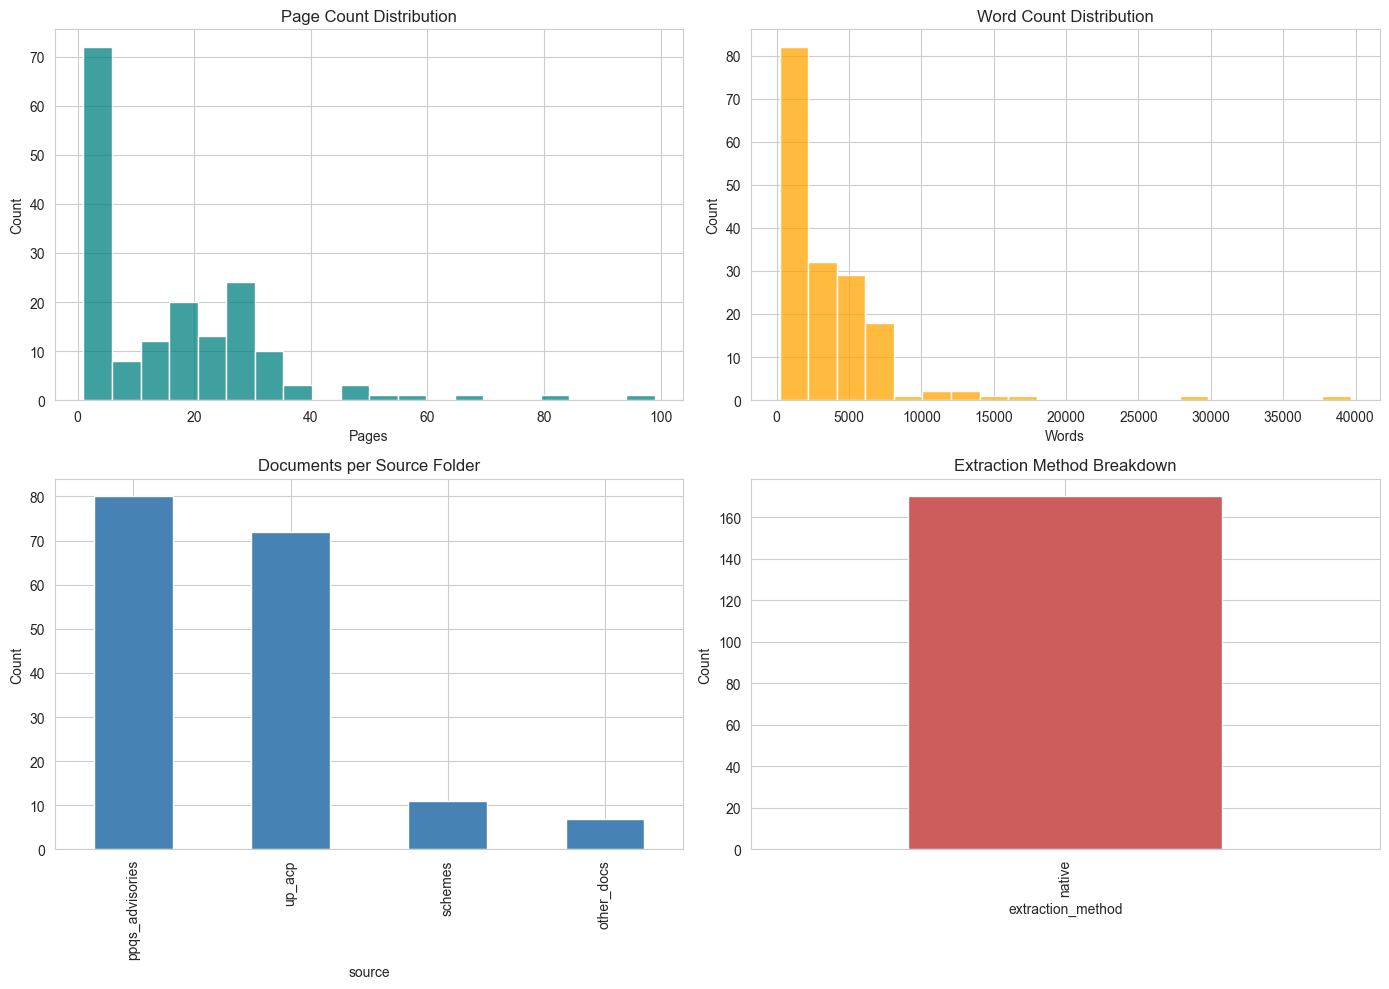

In [39]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Rows in clean_inventory_df:", len(clean_inventory_df))

plt.close('all')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(clean_inventory_df["page_count"].dropna(), bins=20, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Page Count Distribution")
axes[0, 0].set_xlabel("Pages")

sns.histplot(clean_inventory_df["word_count"].dropna(), bins=20, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Word Count Distribution")
axes[0, 1].set_xlabel("Words")

clean_inventory_df["source"].value_counts().plot(kind="bar", ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("Documents per Source Folder")
axes[1, 0].set_ylabel("Count")

clean_inventory_df["extraction_method"].value_counts().plot(kind="bar", ax=axes[1, 1], color="indianred")
axes[1, 1].set_title("Extraction Method Breakdown")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "corpus_overview.png"), dpi=150)
plt.show()

## 6. Save Outputs

In [40]:
clean_inventory_df.to_csv(os.path.join(OUTPUT_DIR, "pdf_inventory_clean.csv"), index=False)
print("Final clean corpus saved with all EDA columns:")
print(f" - {len(clean_inventory_df)} documents")
print(f" - Columns: {list(clean_inventory_df.columns)}")


Final clean corpus saved with all EDA columns:
 - 170 documents
 - Columns: ['source', 'filename', 'filepath', 'size_kb', 'page_count', 'file_hash', 'is_exact_duplicate', 'extraction_method', 'extraction_error', 'char_count', 'word_count', 'text_output_path', 'retry_status', 'detected_language', 'garbage_char_ratio', 'detected_year']


# PDF Corpus Chunking — RAG / NLP Track (Milestone 2 → 3 prep)

Chunks the cleaned PDF text corpus (`pdf_inventory_clean.csv` + extracted `.txt` files)
into MuRIL-ready chunks: sentence-aware, ~512 tokens per chunk, 50-token overlap.

In [41]:
!pip install nltk tiktoken pandas --break-system-packages -q
import os
import re
import json
import pandas as pd
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
CLEAN_CSV = "../data/raw/pdfs/pdf_eda_outputs/pdf_inventory_clean.csv"
CHUNK_SIZE_TOKENS = 512
CHUNK_OVERLAP_TOKENS = 50
OUT_PATH = "../data/processed/pdf_chunks.jsonl"

clean_df = pd.read_csv(CLEAN_CSV)
print(f"Documents to chunk: {len(clean_df)}")
clean_df.head()


Documents to chunk: 170


,source,filename,filepath,size_kb,page_count,file_hash,is_exact_duplicate,extraction_method,extraction_error,char_count,word_count,text_output_path,retry_status,detected_language,garbage_char_ratio,detected_year
0,other_docs,CMP_Circulars_29102025_638973560481999250_Rabi...,../data/raw/pdfs/Other_docs\CMP_Circulars_2910...,2178.2,8,3e154fdec3526b3bfa17cb0d9dba4e7614e9b81e55da75...,False,native,NaN,9843,1613,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...,not_applicable,en,0.011,2025.0
1,other_docs,EB-52-Wheat-Cultivation-in-India-Pocket-Guide.pdf,../data/raw/pdfs/Other_docs\EB-52-Wheat-Cultiv...,950.9,40,cbe436b0c8e06360ae61eaa35a0662c85e45c7b6754ae0...,False,native,NaN,45289,7451,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...,not_applicable,en,0.001,NaN
2,other_docs,Indian_Farming_November_2025.pdf,../data/raw/pdfs/Other_docs\Indian_Farming_Nov...,8532.8,68,cc238b69b87b88e138d4015a0e10228ec3296bc5917529...,False,native,NaN,249167,39689,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...,not_applicable,en,0.005,2025.0
3,other_docs,LeafblightSouvenirArticle.pdf.pdf,../data/raw/pdfs/Other_docs\LeafblightSouvenir...,5453.9,7,d6dc5c62098d58743570280990a10c35a39e2c7107c136...,False,native,NaN,3957,583,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...,not_applicable,en,0.014,2024.0
4,other_docs,National_Mission_on_Natural_Farming.pdf,../data/raw/pdfs/Other_docs\National_Mission_o...,480.7,49,9609c0fccef76cb3a9c45287a58157c7c3c6ef03f0628d...,False,native,NaN,87666,13568,../data/raw/pdfs/pdf_eda_outputs\extracted_tex...,not_applicable,en,0.003,NaN


In [43]:
def word_tokenize_count(text):
    return len(text.split())

def hard_split(text, chunk_size):
    words = text.split()
    return [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]

def chunk_sentences(sentences, chunk_size, overlap):
    expanded = []
    for sent in sentences:
        if word_tokenize_count(sent) > chunk_size:
            expanded.extend(hard_split(sent, chunk_size))
        else:
            expanded.append(sent)
    sentences = expanded

    chunks = []
    current, current_len = [], 0
    for sent in sentences:
        sent_len = word_tokenize_count(sent)
        if current_len + sent_len > chunk_size and current:
            chunks.append(" ".join(current))
            overlap_sents, overlap_len = [], 0
            for s in reversed(current):
                l = word_tokenize_count(s)
                if overlap_len + l > overlap:
                    break
                overlap_sents.insert(0, s)
                overlap_len += l
            current, current_len = overlap_sents, overlap_len
        current.append(sent)
        current_len += sent_len
    if current:
        chunks.append(" ".join(current))
    return chunks


In [44]:
all_chunks = []
for _, row in clean_df.iterrows():
    path = row["text_output_path"]
    if not os.path.exists(path):
        continue
    with open(path, encoding="utf-8") as f:
        text = f.read()
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        continue
    sentences = sent_tokenize(text)
    doc_chunks = chunk_sentences(sentences, CHUNK_SIZE_TOKENS, CHUNK_OVERLAP_TOKENS)
    for i, chunk_text in enumerate(doc_chunks):
        all_chunks.append({
            "chunk_id": f"{row['filename']}_{i:03d}",
            "source": row["source"],
            "filename": row["filename"],
            "chunk_index": i,
            "chunk_text": chunk_text,
            "token_count": word_tokenize_count(chunk_text),
            "detected_language": row.get("detected_language", None),
            "detected_year": row.get("detected_year", None),
        })

chunks_df = pd.DataFrame(all_chunks)
print(f"Total chunks: {len(chunks_df)}")
print(f"Avg chunks/doc: {len(chunks_df) / clean_df['filename'].nunique():.1f}")
chunks_df["token_count"].describe()


Total chunks: 1451
Avg chunks/doc: 8.5


count    1451.000000
mean      433.263267
std       108.245715
min         4.000000
25%       395.000000
50%       481.000000
75%       504.000000
max       561.000000
Name: token_count, dtype: float64

In [45]:
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    for _, row in chunks_df.iterrows():
        f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")

chunks_df.to_csv("../data/processed/pdf_chunks.csv", index=False)
print(f"Saved: {OUT_PATH}")
print(f"Saved: ../data/processed/pdf_chunks.csv")


Saved: ../data/processed/pdf_chunks.jsonl
Saved: ../data/processed/pdf_chunks.csv


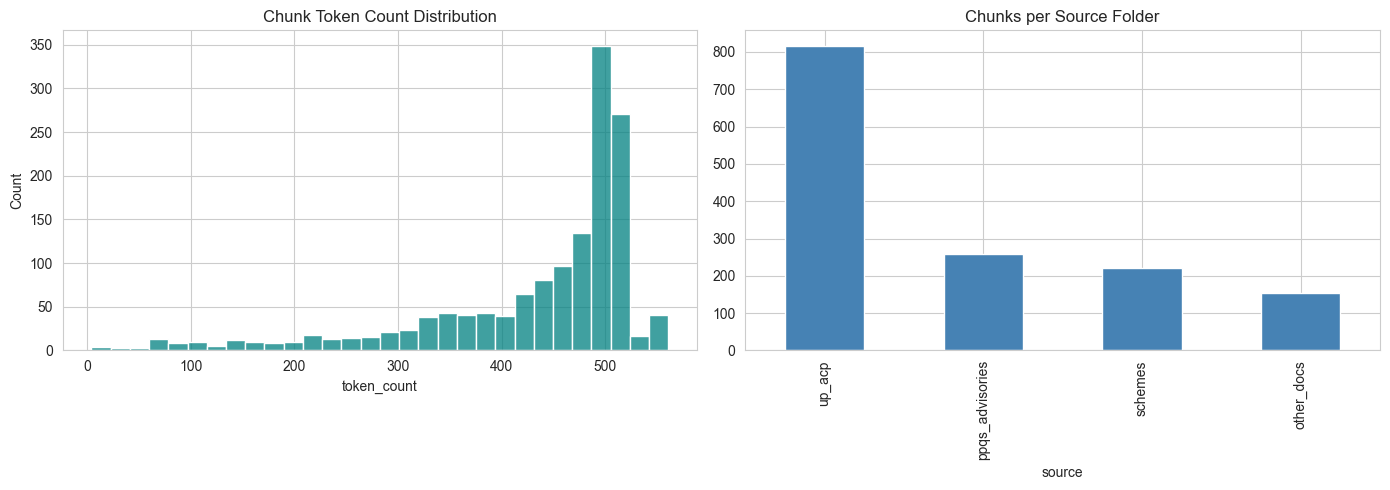

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(chunks_df["token_count"], bins=30, ax=axes[0], color="teal")
axes[0].set_title("Chunk Token Count Distribution")

chunks_df["source"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Chunks per Source Folder")

plt.tight_layout()
plt.savefig("../data/processed/chunk_distribution.png", dpi=150)
plt.show()


In [47]:
print(chunks_df.iloc[0]["chunk_text"][:400])


F. No.3-1/2025-NFSNM l[[{d SaO-R/ Government of lndia Eft\rdfu-gtq6-gMriTfdql Mintstry of Agricutture and Farmers Wetfare Ffr\r?ifu-gHoEMftrflrl/ Department of Agriculture and Farmers Welfare 6trfl qqfq/ Pulses Division Krishi Bhawan, New Delhi, Dated: 18t' October, 2025 To, The Commissioner/Director of Agriculture, Governments of Andhra Pradesh, Assam, Bihar, Chhattisgarh, Gujarat, Haryana, Jhark
